# 📊 Diário de Sprints - 3WB-10

**Projeto:** Projeto 3WB-10
**Dataset:** [Nome/Link do Dataset]
**Repositório:** [Link GitHub/GitLab se houver]

## 👥 Membros do Grupo

| Nome | Matrícula | GitHub/Email | Papéis no Projeto |
|------|-----------|--------------|-------------------|
| DIOGO ADARIO MARASSI | a2220354 | [GitHub/Email] | ☐ Data Engineering ☐ Documentation ☐ ML Modeling ☐ Visualization ☐ Research |
| BRENO BRAGA NEVES | a2310590 | [GitHub/Email] | ☐ Data Engineering ☐ Documentation ☐ ML Modeling ☐ Visualization ☐ Research |

### 📝 Legenda de Papéis:
- **Data Engineering:** Limpeza, pré-processamento, pipelines
- **ML Modeling:** Desenvolvimento e otimização de modelos
- **Visualization:** Gráficos, dashboards, apresentações visuais
- **Research:** Pesquisa bibliográfica, estado da arte, benchmarks
- **Documentation:** Relatórios, documentação de código, atas

---

## 📌 Visão Geral do Projeto

### Problem Statement
O problema são dispositivos IoT, redes domésticas e corporativas sendo alvos frequentes de malwares como Mirai e Okiru. Nossa ideia é identificar automaticamente comportamentos maliciosos, e categorizar o tipo de ataque, permitindo assim uma resposta mais rápida a ameaças e reduz a dependência de análise manual por especialistas em segurança.

### Objetivos
- **Principal:** Classificar fluxos de tráfego de rede de dispositivos IoT como benignos ou maliciosos com alta acurácia
- **Secundário:**
- Classificar multiclasse o tipo específico de ataque (DDoS, C&C, PortScan, Okiru, etc.)
- **Terciários:**
- Identificar quais features de rede são mais relevantes para distinguir tráfego malicioso
- Avaliar o impacto do desbalanceamento de classes na performance dos modelos

### Roadmap Geral
- [x] Definição do problema
- [x] Coleta e exploração de dados
- [ ] Pré-processamento e feature engineering
- [ ] Modelagem inicial
- [ ] Otimização e validação
- [ ] Deploy/Apresentação final

---

## 🏃 Sprint 1
**Período:** 07/04/2026 - 28/04/2026
**Foco Principal:** Definição do problema, entendimento dos dados, e exploração inicial. Tratamento de colunas que não agragam à analálise e valores nulos.
**Aula Sprint:** 14/04

### 👥 Presença na Aula Sprint
☑️ DIOGO ☑️ BRENO

### 🎯 Objetivos do Sprint
- Entender a estrutura e o significado de cada coluna do dataset
- Gerar um dataset amostrado e balanceado a partir dos 23 cenários brutos e desbalanceados
- Realizar a exploração inicial e tratar colunas e valores que não agregam ao modelo

### 📊 Trabalho Realizado

#### O que fizemos:
- Montamos uma lógica para pegar uma amostra do dataset sem prejudicar o desbalanceamento (a explicação estará detalhada no documento)
- Exploramos os dados e as colunas. Como não é um assunto trivial, explicaremos cada uma em detalhes no documento.
- Tratamos os valores nulos e explicamos as decisões no documento

### Explicação do dataset

* ts: Timestamp do início da conexão (Unix time)

* uid: Identificador único da conexão gerado pelo Zeek

* id.orig_h: IP de origem (quem iniciou a conexão)

* id.orig_p: Porta de origem

* id.resp_h: IP de destino (quem recebeu a conexão)

* id.resp_p: Porta de destino

* proto: Protocolo de transporte (tcp, udp, icmp)

* service: Protocolo de aplicação detectado pelo Zeek (http, dns, ssh, etc.)

* duration: Duração da conexão em segundos

* orig_bytes: Bytes enviados pela origem

* resp_bytes: Bytes enviados pelo destino em resposta

* conn_state: Estado final da conexão (ex: SF = encerrada normalmente, S0 = sem resposta)

* local_orig: Se a origem é uma máquina da rede local

* local_resp: Se o destino é uma máquina da rede local

* missed_bytes: Bytes perdidos/não capturados durante a conexão

* history: Sequência de eventos da conexão em letras (ex: ShADadFf)

* orig_pkts: Número de pacotes enviados pela origem

* orig_ip_bytes: Total de bytes IP enviados pela origem (inclui cabeçalhos)

* resp_pkts: Número de pacotes enviados pelo destino

* resp_ip_bytes: Total de bytes IP enviados pelo destino (inclui cabeçalhos)

* tunnel_parents: Informações sobre o tunelamento usado ou não pela conexão

* label: Variável alvo 1: Malicious ou Benign

* detailed-label: Variável alvo 2: tipo específico do comportamento (DDoS, C&C, PortScan, etc.) ou - para benigno

* scenario: Coluna adicionada por nós — identifica o cenário de origem do flow


### Desafios


Os principais desafios são: dataset muito grande (40GB), dados separados em diferentes datasets e desbalanceamento extremo entre os datasets e dentro dos datasets

Os dados são divididos em cenários, em que cada cenário tem seu dataset próprio. Esses dados possuiam 2 desbalanceamento claros. Um entre a quantidade de dados de cada cenário, e outro entre a quantidade em cada label em um cenário. Na imagem abaixo possui a representação de 2 cenários (2 tabelas) bem diferentes em relação a quantidade de dados. Além disso, é possível ver o desbalanceamento entre labels interno a cada dataset: (não abra a célula abaixo, pois o base 64 da imagem é muito grande)

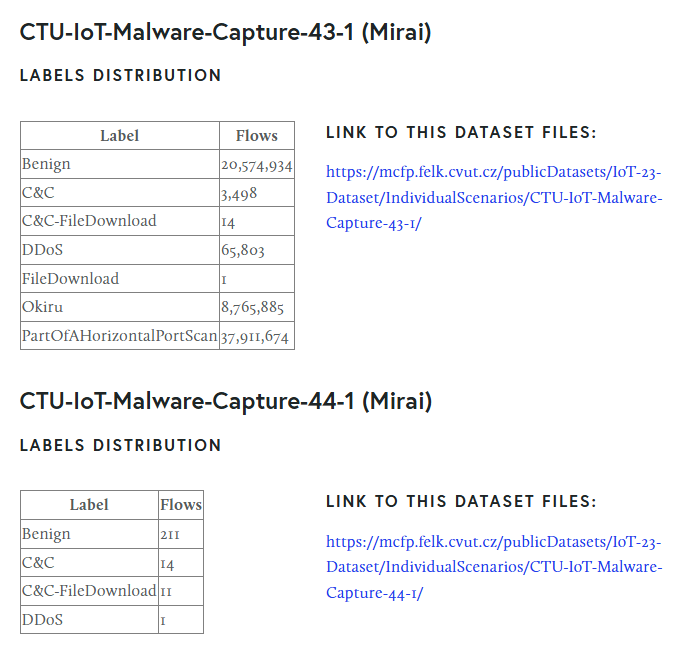

Com isso, caso pegassemos 5% de cada dataset, estaríamos prejudicando ainda mais o desbalanceamento. Por isso pensamos em uma lógica para fazer o sampling de maneira adequada, que será explicada na seção abaixo.

### Solução

#### 1. Estratégia de Sampling e Mitigação de Desbalanceamento

A abordagem divide o tratamento dos dados com base no volume de cada cenário individual. O site do dataset disponibiliza alguns metadados importantes, como um dataset com a distribuição de labels por cenário. Isso é justamente onde está o problema crítico do desbalanceamento.

##### 1.1. Classificação global dos cenários

Os cenários de infecção foram divididos em duas categorias operacionais, adotando-se a média como um limiar de corte 1.000.000 (flows). Esse valor foi escolhido olhando a distribuição dos dados em cada cenário. Com isso, teremos:

* Cenário A (Volume Adequado): Cenários cujo total de fluxos é estritamente menor que 1.000.000.
Ação: Utilização de 100% dos dados. Cenários menores são inseridos completos no projeto, evitando qualquer desperdício de dados estruturados.


* Cenário B (Volume Massivo): Cenários cujo total de fluxos é igual ou superior a 1.000.000.
Ação: Aplicação do algoritmo de redução e balanceamento, detalhado a seguir.

##### 1.2. Lógica de Amostragem para Cenários Massivos (Cenário B)

Para os cenários classificados como massivos (B), definimos um Limiar de Classe Rara de 250.000 fluxos. Esse valor foi escolhido simplesmente a partir da visualização da distribuição de labels por cenário. Fica claro que depois de 250k, começam a surgir classes apenas com milhões de dados, o que faz o valor de 250k adequado. O tratamento desses dados massivos ocorre em três etapas sequenciais:

* Passo 1: Segregação por Frequência (Preservação de Dados):
Classes Raras (< 250.000 fluxos): São preservadas integralmente. É garantida a extração de 100% das amostras dessas categorias.
Classes Não Raras (≥ 250.000 fluxos): São separadas do conjunto principal para passarem pelo processo de equalização. São casos em que temos milhões de amostras.


* Passo 2: Equalização das Classes Majoritárias:
Dentre as classes não raras segregadas, identifica-se aquela que possui a menor quantidade absoluta de fluxos.
Todas as demais classes majoritárias recebem um "teto" (cap) limitando-as a esse mesmo valor mínimo.
Resultado do Passo: Todas as classes abundantes são niveladas.


* Passo 3: Aplicação de 5%:
Como já vimos, definimos um orçamento máximo de processamento equivalente a 5% do total original de fluxos daquele cenário.
Garante-se inicialmente o "pagamento" deste orçamento com os fluxos das classes raras (que nunca ultrapassam esse teto de 5% em cenários massivos (B)).
O volume excedente do orçamento é distribuído aplicando-se uma porcentagem igual de extração sobre as classes não raras previamente equalizadas, até que o cenário atinja os 5% desejados.






### 📝 Decisões Importantes
1. **[Não usar um sampling fixo para reduzir o dataset]:** Isso prejudicaria ainda mais o desbalanceamento


### 💬 Feedback do Professor/Monitor
> "[Feedback recebido durante a aula sprint]"

### ➡️ Próximos Passos
- [ ] [Tarefa 1] - Responsável: [Nome] - Prazo: [data]
- [ ] [Tarefa 2] - Responsável: [Nome] - Prazo: [data]
- [ ] [Tarefa 3] - Responsável: [Nome] - Prazo: [data]

### 📊 Progresso do Sprint
- **Tarefas iniciais:** [3]
- **Tarefas adicionadas:** [2] *(descobertas durante o desenvolvimento)*
- **Conclusão:** [4/5 tarefas finalizadas]
- **Principais entregas:**
 - [Ex: Dataset limpo e analisado]
 - [Ex: Primeiro modelo treinado]
 - [Ex: Documentação atualizada]

---

## 🏃 Sprint 2
**Período:** [dd/mm a dd/mm]
**Foco Principal:** [Ex: Limpeza de dados e feature engineering]
**Aula Sprint:** [dd/mm - Aula 17]

### 👥 Presença na Aula Sprint
☐ DIOGO ☐ BRENO

### 🎯 Objetivos do Sprint
- [ ] [Objetivo 1 específico para este sprint]
- [ ] [Objetivo 2 específico para este sprint]
- [ ] [Objetivo 3 específico para este sprint]

### 📊 Trabalho Realizado

#### O que fizemos:
[Descrever principais atividades e decisões]

### 🚧 Desafios e Soluções

| Desafio | Solução Adotada | Status |
|---------|-----------------|--------|
| [Descrever desafio] | [Solução adotada] | ⏳ Em andamento |
| [Descrever desafio] | [Solução adotada] | ✅ Resolvido |

### 📝 Decisões Importantes
1. **[Decisão]:** [Justificativa]
2. **[Decisão]:** [Justificativa]

### 💬 Feedback do Professor/Monitor
> "[Feedback recebido durante a aula sprint]"

### ➡️ Próximos Passos
- [ ] [Tarefa 1] - Responsável: [Nome] - Prazo: [data]
- [ ] [Tarefa 2] - Responsável: [Nome] - Prazo: [data]
- [ ] [Tarefa 3] - Responsável: [Nome] - Prazo: [data]

### 📊 Progresso do Sprint
- **Tarefas iniciais:** [número]
- **Tarefas adicionadas:** [número] *(descobertas durante o desenvolvimento)*
- **Conclusão:** [X/Y tarefas finalizadas]
- **Principais entregas:**
 - [Listar entrega concreta 1]
 - [Listar entrega concreta 2]
 - [Listar entrega concreta 3]

---

## 🏃 Sprint 3
**Período:** [dd/mm a dd/mm]
**Foco Principal:** [Definir conforme necessidade do grupo]
**Aula Sprint:** [dd/mm - Aula 21]

### 👥 Presença na Aula Sprint
☐ DIOGO ☐ BRENO

### 🎯 Objetivos do Sprint
- [ ] [Objetivo 1 específico para este sprint]
- [ ] [Objetivo 2 específico para este sprint]
- [ ] [Objetivo 3 específico para este sprint]

### 📊 Trabalho Realizado

#### O que fizemos:
[Descrever principais atividades e decisões]

### 🚧 Desafios e Soluções

| Desafio | Solução Adotada | Status |
|---------|-----------------|--------|
| [Descrever desafio] | [Solução adotada] | ⏳ Em andamento |
| [Descrever desafio] | [Solução adotada] | ✅ Resolvido |

### 📝 Decisões Importantes
1. **[Decisão]:** [Justificativa]
2. **[Decisão]:** [Justificativa]

### 💬 Feedback do Professor/Monitor
> "[Feedback recebido durante a aula sprint]"

### ➡️ Próximos Passos
- [ ] [Tarefa 1] - Responsável: [Nome] - Prazo: [data]
- [ ] [Tarefa 2] - Responsável: [Nome] - Prazo: [data]
- [ ] [Tarefa 3] - Responsável: [Nome] - Prazo: [data]

### 📊 Progresso do Sprint
- **Tarefas iniciais:** [número]
- **Tarefas adicionadas:** [número] *(descobertas durante o desenvolvimento)*
- **Conclusão:** [X/Y tarefas finalizadas]
- **Principais entregas:**
 - [Listar entrega concreta 1]
 - [Listar entrega concreta 2]
 - [Listar entrega concreta 3]

---

## 🏃 Sprint 4
**Período:** [dd/mm a dd/mm]
**Foco Principal:** [Definir conforme necessidade do grupo]
**Aula Sprint:** [dd/mm - Aula 24]

### 👥 Presença na Aula Sprint
☐ DIOGO ☐ BRENO

### 🎯 Objetivos do Sprint
- [ ] [Objetivo 1 específico para este sprint]
- [ ] [Objetivo 2 específico para este sprint]
- [ ] [Objetivo 3 específico para este sprint]

### 📊 Trabalho Realizado

#### O que fizemos:
[Descrever principais atividades e decisões]

### 🚧 Desafios e Soluções

| Desafio | Solução Adotada | Status |
|---------|-----------------|--------|
| [Descrever desafio] | [Solução adotada] | ⏳ Em andamento |
| [Descrever desafio] | [Solução adotada] | ✅ Resolvido |

### 📝 Decisões Importantes
1. **[Decisão]:** [Justificativa]
2. **[Decisão]:** [Justificativa]

### 💬 Feedback do Professor/Monitor
> "[Feedback recebido durante a aula sprint]"

### ➡️ Próximos Passos
- [ ] [Tarefa 1] - Responsável: [Nome] - Prazo: [data]
- [ ] [Tarefa 2] - Responsável: [Nome] - Prazo: [data]
- [ ] [Tarefa 3] - Responsável: [Nome] - Prazo: [data]

### 📊 Progresso do Sprint
- **Tarefas iniciais:** [número]
- **Tarefas adicionadas:** [número] *(descobertas durante o desenvolvimento)*
- **Conclusão:** [X/Y tarefas finalizadas]
- **Principais entregas:**
 - [Listar entrega concreta 1]
 - [Listar entrega concreta 2]
 - [Listar entrega concreta 3]

---

## 🏃 Sprint 5
**Período:** [dd/mm a dd/mm]
**Foco Principal:** [Ex: Preparação final e apresentação]
**Aula Sprint:** [dd/mm - Aula 28]

### 👥 Presença na Aula Sprint
☐ DIOGO ☐ BRENO

### 🎯 Objetivos do Sprint
- [ ] [Objetivo 1 específico para este sprint]
- [ ] [Objetivo 2 específico para este sprint]
- [ ] [Objetivo 3 específico para este sprint]

### 📊 Trabalho Realizado

#### O que fizemos:
[Descrever principais atividades e decisões]

### 🚧 Desafios e Soluções

| Desafio | Solução Adotada | Status |
|---------|-----------------|--------|
| [Descrever desafio] | [Solução adotada] | ⏳ Em andamento |
| [Descrever desafio] | [Solução adotada] | ✅ Resolvido |

### 📝 Decisões Importantes
1. **[Decisão]:** [Justificativa]
2. **[Decisão]:** [Justificativa]

### 💬 Feedback do Professor/Monitor
> "[Feedback recebido durante a aula sprint]"

### ➡️ Próximos Passos
- [ ] [Tarefa 1] - Responsável: [Nome] - Prazo: [data]
- [ ] [Tarefa 2] - Responsável: [Nome] - Prazo: [data]
- [ ] [Tarefa 3] - Responsável: [Nome] - Prazo: [data]

### 📊 Progresso do Sprint
- **Tarefas iniciais:** [número]
- **Tarefas adicionadas:** [número] *(descobertas durante o desenvolvimento)*
- **Conclusão:** [X/Y tarefas finalizadas]
- **Principais entregas:**
 - [Listar entrega concreta 1]
 - [Listar entrega concreta 2]
 - [Listar entrega concreta 3]

---

## 📝 Reflexão e Autoavaliação

### 🤝 Dinâmica do Grupo

#### Contribuição Individual (Autoavaliação)
| Membro | Sprint 1 | Sprint 2 | Sprint 3 | Sprint 4 | Sprint 5 | Comentários |
|--------|----------|----------|----------|----------|----------|-------------|
| DIOGO | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐☆ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐☆ | ⭐⭐⭐⭐⭐ | [Opcional] |
| BRENO | ⭐⭐⭐⭐☆ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐☆ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐☆ | [Opcional] |
| [Nome3] | ⭐⭐⭐⭐⭐ | ⭐⭐⭐☆☆ | ⭐⭐⭐⭐☆ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ | [Opcional] |
| [Nome4] | ⭐⭐⭐⭐☆ | ⭐⭐⭐⭐☆ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐☆☆ | ⭐⭐⭐⭐⭐ | [Opcional] |

*Escala: ⭐ (mínima) a ⭐⭐⭐⭐⭐ (máxima contribuição)*

### 💪 Pontos Fortes do Grupo
1. [Ex: Boa comunicação e organização]
2. [Ex: Domínio técnico em Python]
3. [Ex: Criatividade nas soluções]

### 🎯 Áreas de Melhoria
1. [Ex: Gestão de tempo]
2. [Ex: Documentação mais detalhada]
3. [Ex: Testes mais rigorosos]

### 🔄 O que faríamos diferente?
[Reflexão sobre o processo completo - o que mudaria se pudesse recomeçar o projeto]

### 🏆 Maiores Conquistas
1. [Conquista técnica mais importante]
2. [Conquista de trabalho em equipe]
3. [Aprendizado mais valioso]

---

**Última atualização:** [dd/mm/yyyy às hh:mm]
**Versão:** 1.0

## 📊 Resumo do Projeto

### 🎯 Resultados Alcançados

#### Métricas do Modelo Final
| Métrica | Valor | Meta | Status |
|---------|-------|------|--------|
| Acurácia | XX% | 85% | 🟢/🟡/🔴 |
| F1-Score | X.XX | X.XX | 🟢/🟡/🔴 |
| Recall | XX% | XX% | 🟢/🟡/🔴 |
| Precision | XX% | XX% | 🟢/🟡/🔴 |

#### Entregáveis
- [ ] Notebook com análise completa
- [ ] Modelo treinado e validado
- [ ] Apresentação final
- [ ] Documentação
- [ ] [Outros entregáveis específicos]

### 🔍 Principais Aprendizados

#### Técnico
1.
2.
3.

#### Trabalho em Equipe
1.
2.

### 🚀 Possíveis Melhorias Futuras
-
-
-

---